# ECG Image Classification using Transfer Learning (MobileNetV2)

This project classifies ECG images into four cardiac condition categories using a MobileNetV2 backbone pretrained on ImageNet, fine-tuned for this task. Transfer learning was chosen over a from-scratch CNN because the dataset (~900 images) is too small to reliably learn visual features from zero; reusing pretrained features avoids overfitting and gives far better generalization. MobileNetV2 specifically was chosen because it is lightweight enough to train in a reasonable time on CPU-only hardware, unlike heavier backbones (ResNet50, EfficientNet). The workflow includes data preprocessing, model training (frozen backbone, with an optional fine-tuning stage), evaluation, and performance analysis.


# Import Libraries

In [ ]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report


In [7]:
# Random seeds for reproducible results
tf.random.set_seed(42)
np.random.seed(42)

# Check GPU

In [8]:
print("GPU Devices:", tf.config.list_physical_devices('GPU'))

GPU Devices: []


# Dataset Information

## Dataset Overview

This project uses the **ECG Images Dataset of Cardiac Patients (Version 2)** from **Mendeley Data**. The objective is to classify ECG images into four cardiac conditions using transfer learning (MobileNetV2).

### Cardiac Classes

| Class | Training Images |
|:------|---------------:|
| 🟢 Normal ECG | **281** |
| 🟡 History of Myocardial Infarction | **169** |
| 🔴 Myocardial Infarction | **236** |
| 🔵 Abnormal Heartbeat | **230** |

### Dataset Summary

- **Number of Classes:** 4
- **Total Labeled Images:** 916 (split into train / validation / test below)
- **Image Size:** 160 × 160 pixels (downscaled from the original 224 × 224 to speed up CPU training; MobileNetV2 supports this resolution natively)
- **Input Channels:** RGB (3 Channels)
- **Framework:** TensorFlow / Keras

Because the original `test` folder only contained a handful of images per class, an 80/20 split of the `train` folder is used to create a proper validation set during training (see Data Generator section). The separate `test` folder is reserved purely for final, untouched evaluation.


In [9]:
# Dataset paths
data_dir = r'ECG_DATA'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

# Data Preprocessing

The following preprocessing techniques were applied before training:

- Resize images to **160 × 160** (reduced from 224×224 for faster CPU training)
- Normalize pixel values (`1/255`)
- Random rotation
- Random zoom
- Width/height shifting
- Shear transformation
- Brightness augmentation
- 80/20 train/validation split (`validation_split`), so the model is validated on held-out images every epoch instead of the tiny external test folder

These preprocessing techniques increase data diversity and help the model generalize better despite the small dataset size. The test set (`test_datagen`) is only rescaled, with no augmentation, since it must reflect real, unaltered images.


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    fill_mode='nearest',
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)


# Data Generators

Three generators are created: `train_generator` and `val_generator` (both drawn from the `train` folder via `validation_split=0.2`, so validation images are never seen during training), and `test_generator` (drawn from the separate `test` folder, used only for the final evaluation).


In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(160,160),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(160,160),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(160,160),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


In [12]:
print(train_generator.class_indices)

{'ECG Images of Myocardial Infarction Patients (240x12=2880)': 0, 'ECG Images of Patient that have History of MI (172x12=2064)': 1, 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)': 2, 'Normal Person ECG Images (284x12=3408)': 3}


# Data Visualization

Found 868 images belonging to 4 classes.


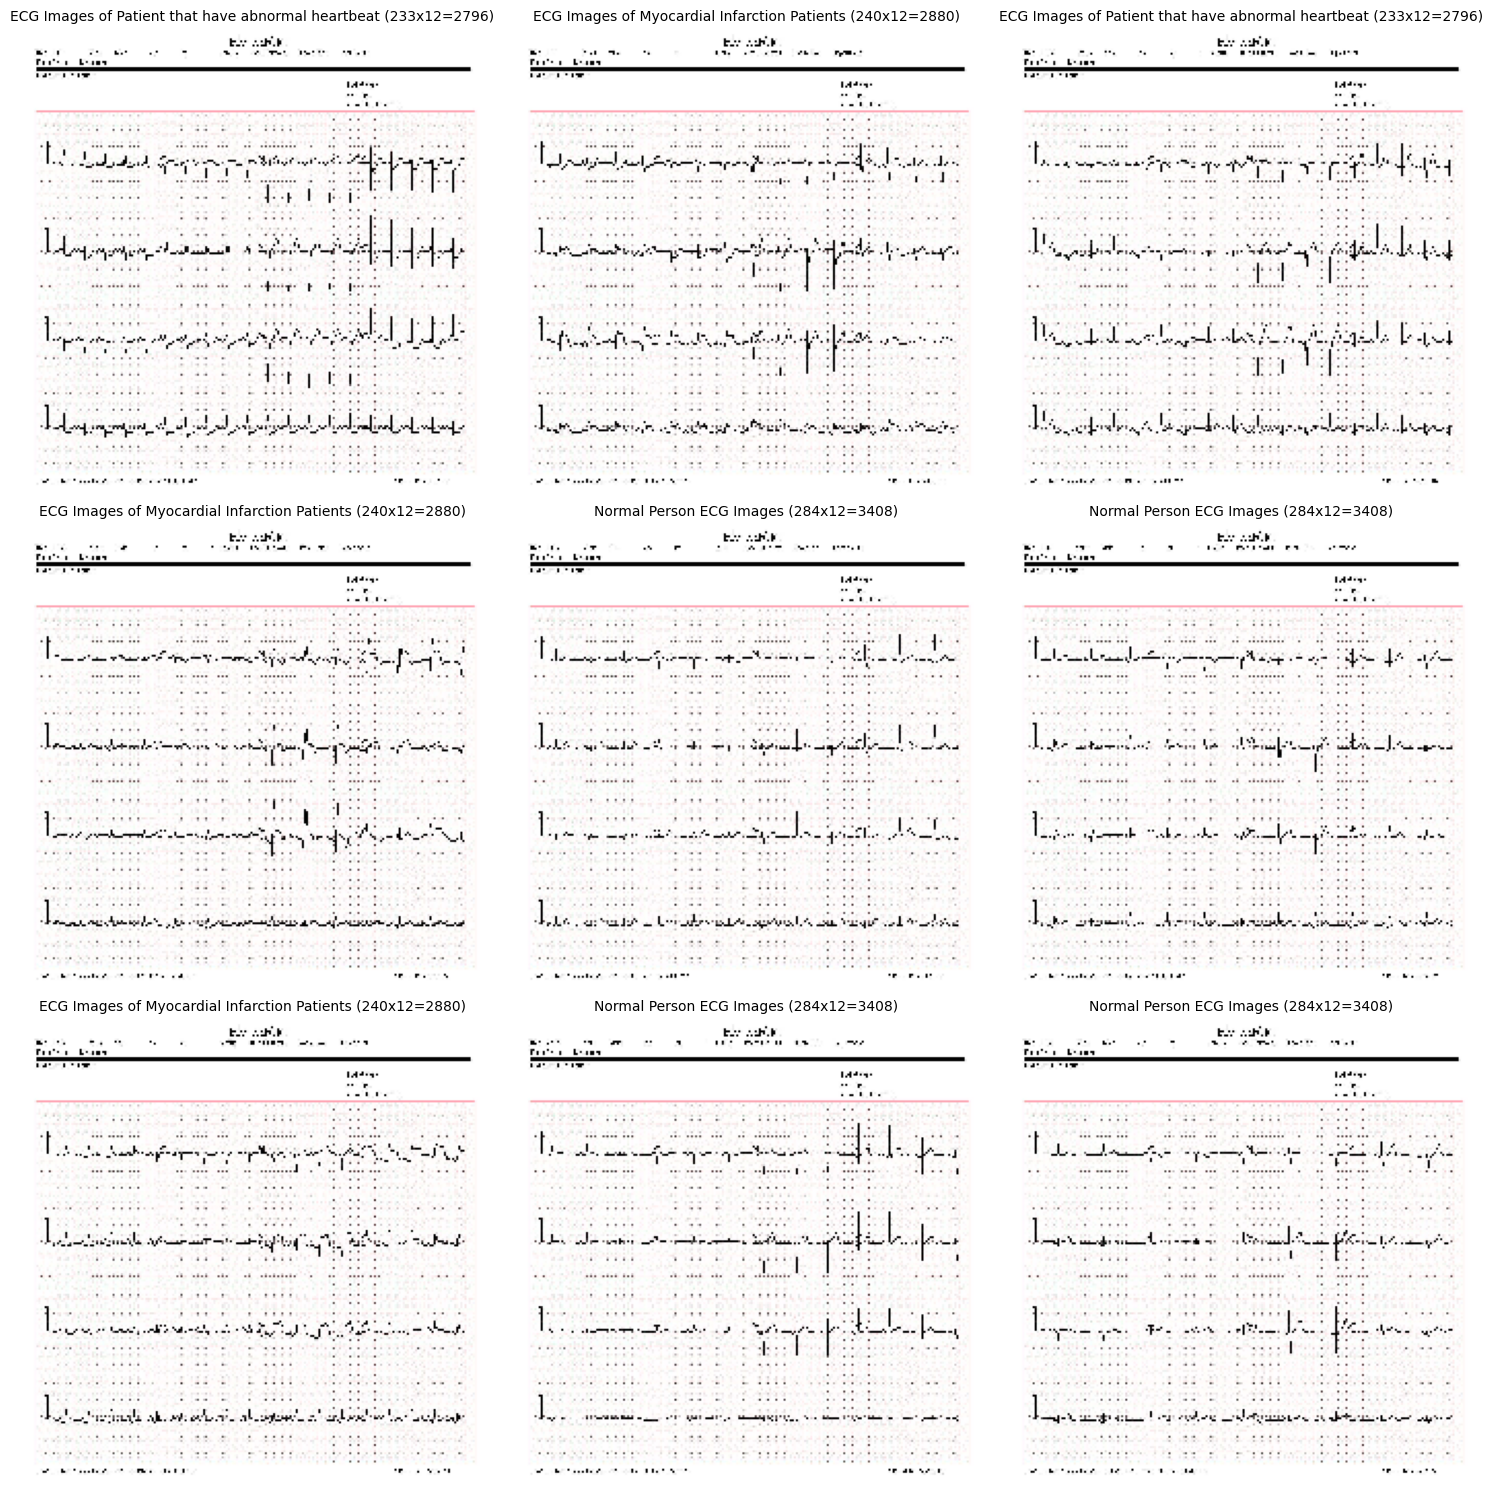

In [13]:
# Create a generator for visualization
display_datagen = ImageDataGenerator(rescale=1./255)

display_generator = display_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=9,
    class_mode='categorical',
    shuffle=True
)
# Get one batch of images and labels
images, labels = next(display_generator)

# Get class names
class_names = list(display_generator.class_indices.keys())

plt.figure(figsize=(15,15))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i].argmax()], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Model Architecture

This section presents the model used for ECG image classification. Instead of training a convolutional backbone from scratch (which overfits quickly on ~900 images), this model uses **transfer learning**: a MobileNetV2 backbone pretrained on ImageNet is frozen and used as a fixed feature extractor, with a small trainable classification head on top. MobileNetV2 was chosen over larger backbones (e.g. ResNet50, EfficientNet) specifically because it trains much faster on CPU-only hardware while still providing strong pretrained features. Input resolution is reduced to 160×160 (from MobileNetV2's default 224×224) to further reduce CPU training time; MobileNetV2 supports this resolution natively without needing different pretrained weights.


In [ ]:
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze pretrained weights

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),

    Dense(4, activation='softmax')
])

model.summary()


# Model Training

Compile the model, define the training callbacks (early stopping on validation accuracy, checkpointing the best model, and learning-rate reduction on plateau), and train the classification head with the MobileNetV2 backbone frozen. Class weights are used to counter the moderate class imbalance in the dataset.


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)


In [ ]:
# Train (frozen backbone)
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


# Results

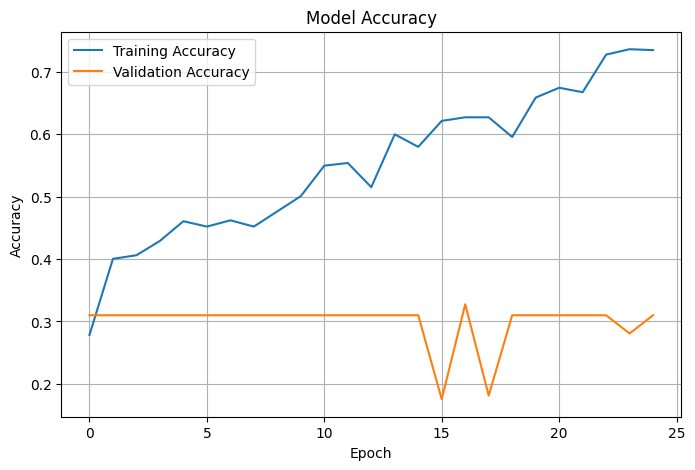

In [21]:
# Accuracy Plot

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

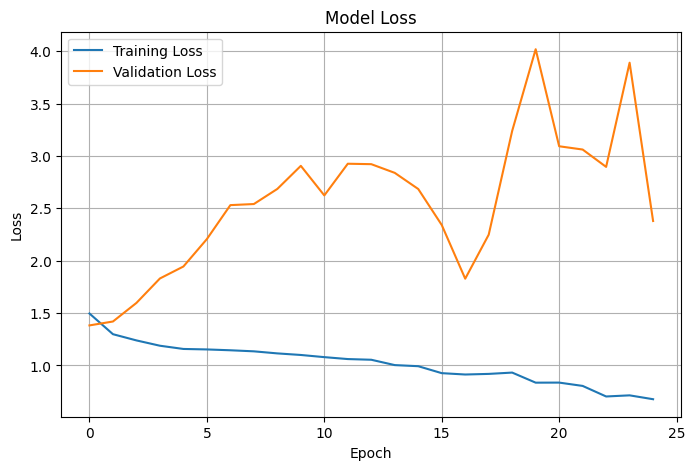

In [22]:

# Loss Plot
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# Evaluation

In [ ]:
best_model = load_model("best_model.keras")

loss, accuracy = best_model.evaluate(test_generator)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


In [ ]:
# Get the ground truth labels
true_labels = test_generator.classes

# Get the label names (folder names)
class_labels = list(test_generator.class_indices.keys())

# Predict the probabilities for the test set
predictions = best_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)


# Confusion Matrix

In [25]:
# Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_classes)

# Print a classification report
print("Classification Report:\n")
print(classification_report(true_labels, predicted_classes, target_names=class_labels))

Classification Report:

                                                    precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients       0.00      0.00      0.00        15
     ECG Images of Patient that have History of MI       0.60      0.20      0.30        15
ECG Images of Patient that have abnormal heartbeat       0.67      0.93      0.78        15
            Normal Person ECG Images (284x12=3408)       0.44      1.00      0.61        15

                                          accuracy                           0.53        60
                                         macro avg       0.43      0.53      0.42        60
                                      weighted avg       0.43      0.53      0.42        60



d:\Model\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Model\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Model\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


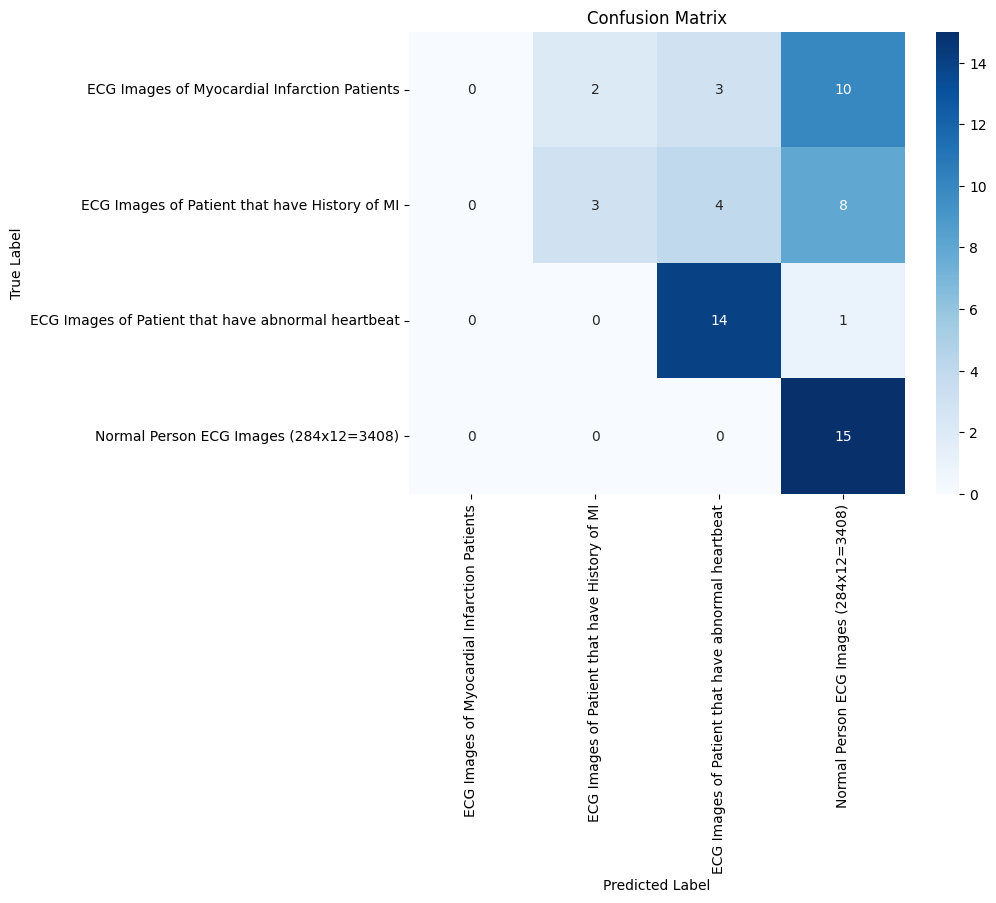

In [26]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Fine-Tuning (Optional)

Once the frozen-backbone model plateaus, unfreeze the top layers of MobileNetV2 and continue training at a very low learning rate. This lets the backbone adapt slightly to ECG images specifically, often giving an additional accuracy boost on top of the frozen-backbone result. Skip this section if the frozen-backbone results above are already satisfactory.


In [ ]:
# Unfreeze the top layers of the backbone for fine-tuning
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


In [ ]:
# Re-evaluate on the test set after fine-tuning
best_model = load_model("best_model.keras")

loss, accuracy = best_model.evaluate(test_generator)
print(f"\nFine-tuned Test Loss: {loss:.4f}")
print(f"Fine-tuned Test Accuracy: {accuracy:.4f}")

predictions = best_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

print("\nClassification Report (fine-tuned):\n")
print(classification_report(true_labels, predicted_classes, target_names=class_labels))


# Saving the Model

In [ ]:
best_model.save("final_model.keras")

print("\nTraining Complete!")
print("Best Model Saved As : best_model.keras")
print("Final Model Saved As: final_model.keras")


# Conclusion

In this project, ECG images were classified into four cardiac conditions using transfer learning with a MobileNetV2 backbone pretrained on ImageNet. A frozen backbone with a small trainable classification head was used to avoid overfitting on the relatively small (~900 image) dataset, with an optional fine-tuning stage to further adapt the top backbone layers to ECG-specific features.

The model was evaluated using accuracy/loss curves, a confusion matrix, and a classification report on a held-out test set, with the best checkpoint (by validation accuracy) used for final evaluation rather than the last-trained weights, to avoid reporting an overfit snapshot.

### Future Improvements
- Increase the dataset size, particularly the test set (currently only ~60 images).
- Try alternative pretrained backbones (e.g. EfficientNetB0, ResNet50) if GPU training becomes available.
- Perform systematic hyperparameter tuning (learning rate, dropout rate, dense layer size).
- Use Grad-CAM for model interpretability, to visualize which regions of the ECG image drive each prediction.
